In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


orders = pd.read_csv('archive/olist_orders_dataset.csv')
reviews = pd.read_csv('archive/olist_order_reviews_dataset.csv')


print("Orders Data Loaded. Here is a preview:")
print(orders.head())

Orders Data Loaded. Here is a preview:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1        

In [4]:
import os
print(os.getcwd())

d:\DATA ANALYST PROJECT


In [5]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

print("Successfully calculated delivery delay for each order!")

Successfully calculated delivery delay for each order!


In [6]:
merged_data = pd.merge(orders, reviews, on='order_id')
final_summary = merged_data.groupby('review_score')['delivery_delay'].mean().reset_index()
final_summary.columns = ['Review Score (Stars)', 'Average Delivery Delay (Days)']
print(final_summary)

   Review Score (Stars)  Average Delivery Delay (Days)
0                     1                      -4.060580
1                     2                      -8.634818
2                     3                     -10.774052
3                     4                     -12.380840
4                     5                     -13.388153


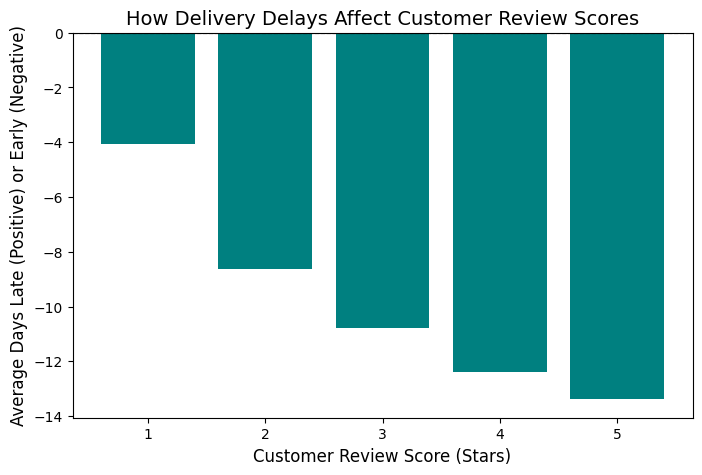

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(final_summary['Review Score (Stars)'], final_summary['Average Delivery Delay (Days)'], color='teal')
plt.title('How Delivery Delays Affect Customer Review Scores', fontsize=14)
plt.xlabel('Customer Review Score (Stars)', fontsize=12)
plt.ylabel('Average Days Late (Positive) or Early (Negative)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Adds a line at 0 days
plt.show()

In [ ]:
items = pd.read_csv('archive/olist_order_items_dataset.csv')
products = pd.read_csv('archive/olist_products_dataset.csv')
translation = pd.read_csv('archive/product_category_name_translation.csv')
product_counts = pd.merge(items, products, on='product_id')
product_counts = pd.merge(product_counts, translation, on='product_category_name')
top_categories = product_counts['product_category_name_english'].value_counts().reset_index()
top_categories.columns = ['Product Category', 'Items Sold']
print("Top 10 Selling Product Categories on Olist:")
print(top_categories.head(10))

FileNotFoundError: [Errno 2] No such file or directory: 'olist_order_items_dataset.csv'